In [16]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv(r"C:\Users\prana\Downloads\archive\health care diabetes.csv")

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [19]:
df = df.iloc[:, 2:]  


In [20]:
df.sample(5)


,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
364,74,25,293,34.9,0.385,30,0
428,94,46,145,40.6,0.284,26,0
647,50,36,159,37.8,0.455,22,1
72,90,0,0,43.4,0.583,42,1
299,72,0,0,23.6,0.840,58,0


In [24]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(
    df.drop('Outcome',axis=1),
    df['Outcome'],
    test_size=0.3,
    random_state=0
)
print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", Y_train.shape)
print("y_test shape :", Y_test.shape)

X_train shape: (537, 6)
X_test shape : (231, 6)
y_train shape: (537,)
y_test shape : (231,)


In [26]:
#standard scaling(z score) (X-U/sigma)
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
scaler.fit(X_train)
X_train_scaled=scaler.transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [27]:
#now scaled values are in numpy array ,so converting in dataframe
X_train_scaled=pd.DataFrame(X_train_scaled,columns=X_train.columns)
X_test_scaled=pd.DataFrame(X_test_scaled,columns=X_test.columns)

In [28]:
np.round(X_train.describe(),1)

,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
count,537.0,537.0,537.0,537.0,537.0,537.0
mean,69.7,21.0,84.9,32.3,0.5,33.7
std,19.5,16.0,118.6,8.0,0.3,12.0
min,0.0,0.0,0.0,0.0,0.1,21.0
25%,64.0,0.0,0.0,27.5,0.2,24.0
50%,72.0,24.0,45.0,32.4,0.4,29.0
75%,80.0,33.0,135.0,36.8,0.6,41.0
max,122.0,99.0,846.0,67.1,2.4,81.0


In [30]:
np.round(X_train_scaled.describe(),1)  #np.round(array_or_dataframe, decimals)
#NumPy function used to round numbers to a specified number of decimal places.

,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
count,537.0,537.0,537.0,537.0,537.0,537.0
mean,-0.0,0.0,0.0,0.0,-0.0,0.0
std,1.0,1.0,1.0,1.0,1.0,1.0
min,-3.6,-1.3,-0.7,-4.0,-1.2,-1.1
25%,-0.3,-1.3,-0.7,-0.6,-0.7,-0.8
50%,0.1,0.2,-0.3,0.0,-0.3,-0.4
75%,0.5,0.7,0.4,0.6,0.4,0.6
max,2.7,4.9,6.4,4.3,5.8,3.9


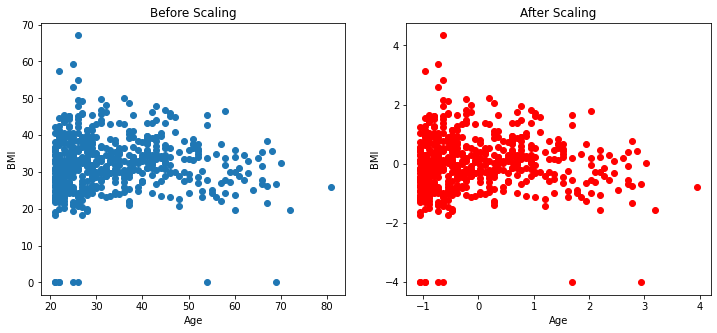

In [31]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12,5))

# Before Scaling
ax1.scatter(X_train['Age'], X_train['BMI'])
ax1.set_title("Before Scaling")
ax1.set_xlabel("Age")
ax1.set_ylabel("BMI")

# After Scaling
ax2.scatter(X_train_scaled['Age'], X_train_scaled['BMI'], color='red')
ax2.set_title("After Scaling")
ax2.set_xlabel("Age")
ax2.set_ylabel("BMI")

plt.show()

# plt.subplots() → Creates a figure with multiple subplots
# fig → Represents the entire figure/canvas
# ax1, ax2 → Individual subplot objects (left and right graph)
# ncols=2 → Creates 2 columns of subplots
# figsize=(12,5) → Sets figure size (width=12, height=5)

# ax1.scatter(x, y) → Scatter plot before scaling
# X_train['Age'] → X-axis values
# X_train['BMI'] → Y-axis values
# set_title() → Adds graph title
# set_xlabel() → Labels X-axis
# set_ylabel() → Labels Y-axis

# ax2.scatter(x, y, color='red') → Scatter plot after scaling
# X_train_scaled → Scaled training data
# color='red' → Sets point color to red

# plt.show() → Displays the figure

<function matplotlib.pyplot.show(close=None, block=None)>

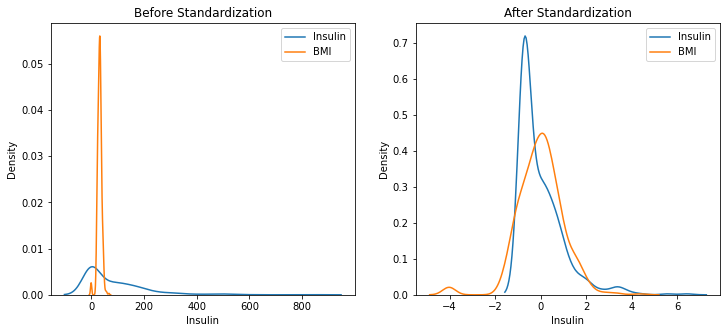

In [34]:
#probability Density Function

fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12,5))

# Before Scaling
sns.kdeplot(X_train['Insulin'], ax=ax1, label='Insulin')
sns.kdeplot(X_train['BMI'], ax=ax1, label='BMI')
ax1.set_title("Before Standardization")
ax1.legend()

# After Scaling
sns.kdeplot(X_train_scaled['Insulin'], ax=ax2, label='Insulin')
sns.kdeplot(X_train_scaled['BMI'], ax=ax2, label='BMI')
ax2.set_title("After Standardization")
ax2.legend()

plt.show

# plt.subplots() → Create figure and subplots.
# sns.kdeplot() → Draw Probability Density Function (PDF).
# ax=ax1 → Plot on first graph.
# label= → Name of the plotted curve.
# set_title() → Add graph title.
# legend() → Display labels of the curves.
# plt.show() → Display the figure.

In [38]:
#logistic Regression need scaled value
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
lr = LogisticRegression()

lr.fit(X_train, Y_train)                  # Train model
Y_pred = lr.predict(X_test)               # Predict test data

print("Accuracy (Original Data):", accuracy_score(Y_test, Y_pred))


# ------------------ Logistic Regression on Scaled Data ------------------

lr_scaled = LogisticRegression()

lr_scaled.fit(X_train_scaled, Y_train)    # Train on scaled data
Y_pred_scaled = lr_scaled.predict(X_test_scaled)   # Predict

print("Accuracy (Scaled Data):", accuracy_score(Y_test, Y_pred_scaled))

Accuracy (Original Data): 0.7229437229437229
Accuracy (Scaled Data): 0.7229437229437229


In [ ]:
# Logistic Regression
# KNN
# SVM
# K-Means
# PCA
# Neural Networks

# for this Apply Standardization